In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import os
import sys
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [4]:
from machines.predictions.svr_prediction import SVR_Prediction
from machines.enums import SvrKernelEnum
from preprocesses.preprocess import Preprocess
from preprocesses.enums import TransformEnum, TypeFileEnum, StandardScaleEnum
from metrics.error_metric import ErrorMetric
from metrics.enums import MetricEnum, PlotLegends

Read the file and prepare data for SVR

In [5]:
file_csv = '../../../data/phenotypic_obregon_151617.csv'
svr = SVR_Prediction(kernel=SvrKernelEnum.LINEAR)
preprocessing =  Preprocess(file_name=file_csv, type_file=TypeFileEnum.CSV)
preprocessing.read_file(
    transform=TransformEnum.PASS,
    standard_scale=StandardScaleEnum.BASIC,
)
preprocessing.build_train_and_test()

Launched SVR

In [6]:
x_train, y_train = preprocessing.get_train()
svr.training(x_train=x_train, y_train=y_train)

In [7]:
x_test, y_test = preprocessing.get_test()
y_predicted = svr.prediction(x_test=x_test)

Get metrics

In [8]:
metric = ErrorMetric(y_predicted=y_predicted, y_test=y_test, x_test=x_test)
metric.calculate_metric_prediction()
print('Root mean squared error -> {}'.format(metric.get_metric(metric=MetricEnum.ROOT_MEAN_SQUARED_ERROR)))
print('R2 -> {}'.format(metric.get_metric(metric=MetricEnum.R2_SCORE)))
print('MAPE -> {}'.format(metric.get_metric(metric=MetricEnum.MEAN_ABSOLUTE_PERCENTAGE_ERROR)))
metric.get_all_from_predict()

Root mean squared error -> 40.66863133041365
R2 -> 0.8282866714637882
MAPE -> 0.041663389450956545


{'d2_absolute_error_score': 0.6404251183611893,
 'd2_pinball_score': 0.6404251183611893,
 'd2_tweedie_score': 0.8282866714637882,
 'explained_variance_score': 0.8285782855099347,
 'max_error': 209.25081192437688,
 'mean_absolute_error': 25.09023849015613,
 'mean_absolute_percentage_error': 0.041663389450956545,
 'mean_gamma_deviance': 0.004636516946077005,
 'mean_poisson_deviance': 2.6679622387816915,
 'mean_squared_error': 1653.9375742891032,
 'mean_squared_log_error': 0.00468192682137089,
 'median_absolute_error': 10.427004469874646,
 'r2_score': 0.8282866714637882,
 'root_mean_squared_error': 40.66863133041365,
 'root_mean_squared_log_error': 0.06842460684118609}

Plots:

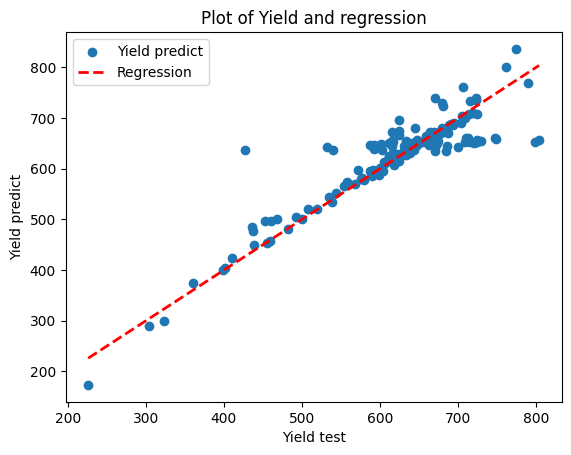

In [9]:
legend = PlotLegends()
legend.first_plot_label = "Yield predict"
legend.second_plot_label = "Regression"
legend.title = "Plot of Yield and regression"
legend.x_label = "Yield test"
legend.y_label = "Yield predict"
metric.plot_true_vs_predicted(legend=legend)


Plot $r^2$

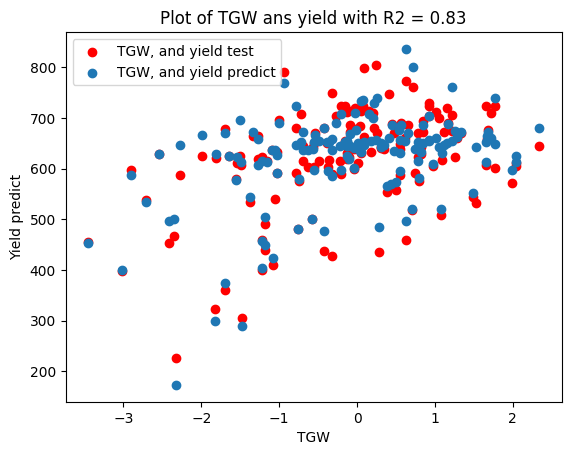

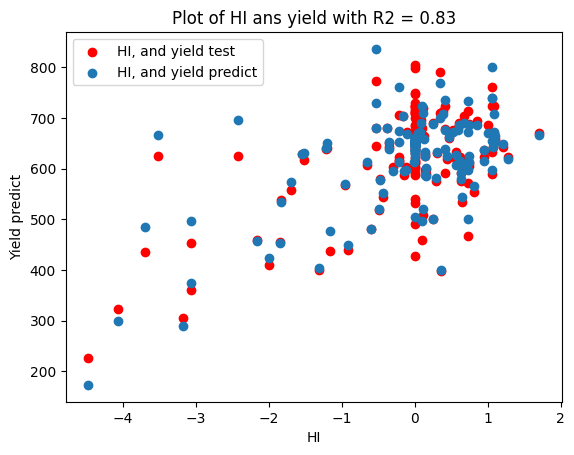

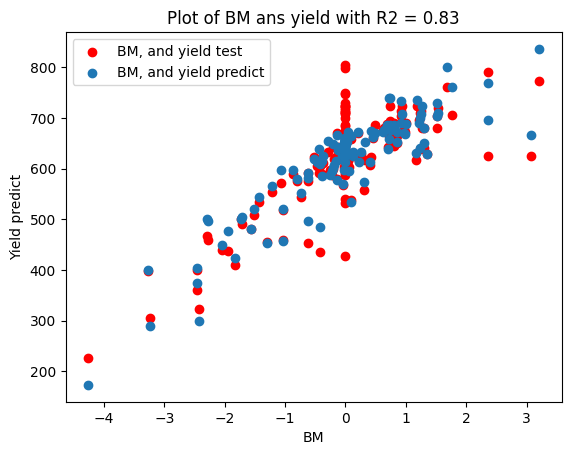

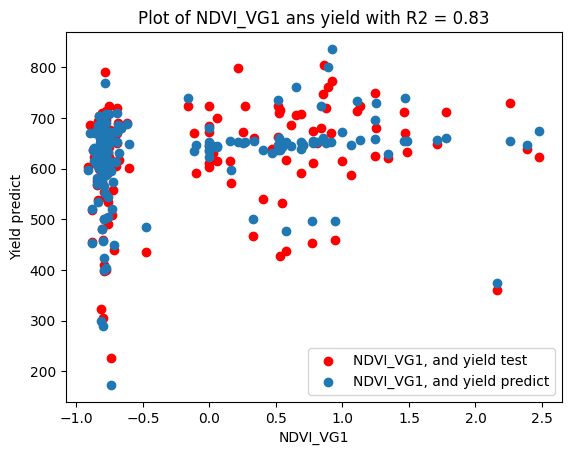

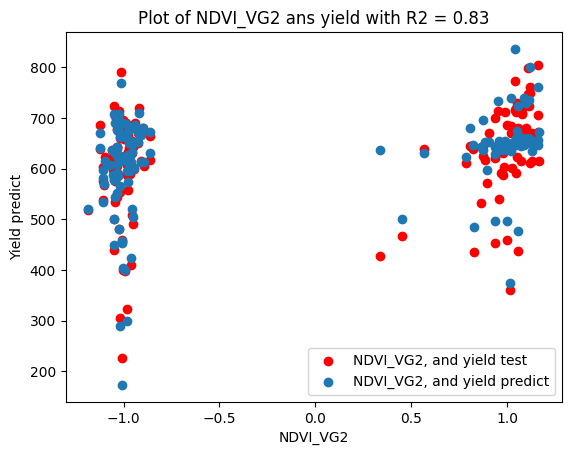

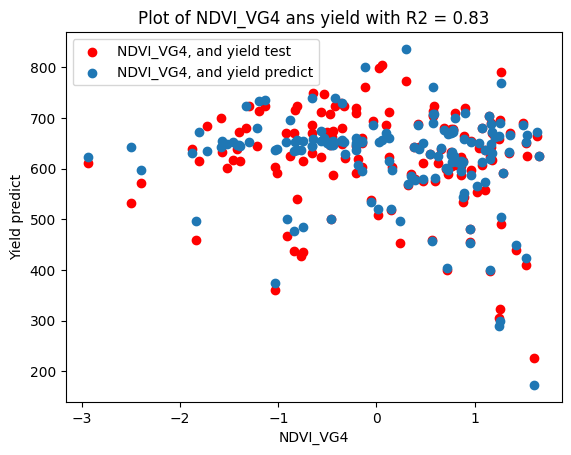

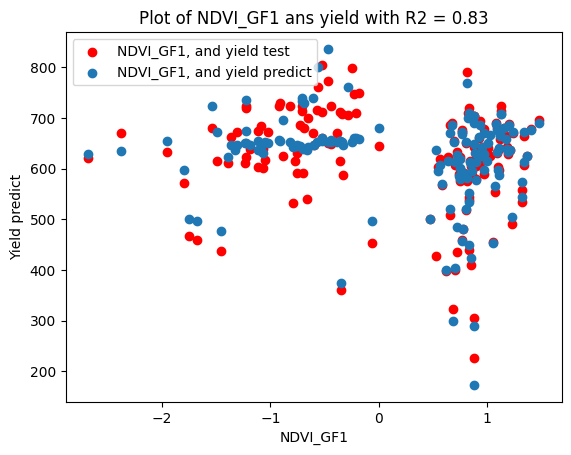

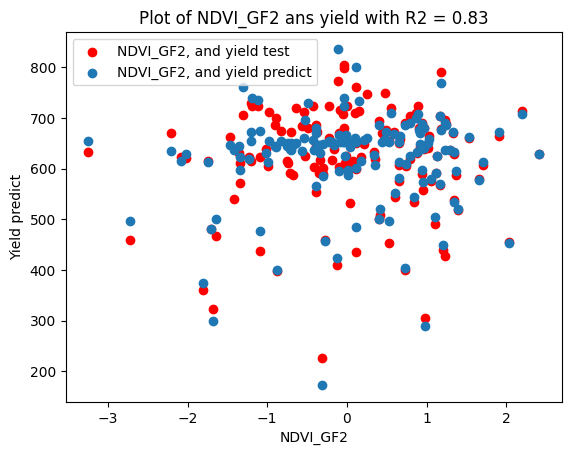

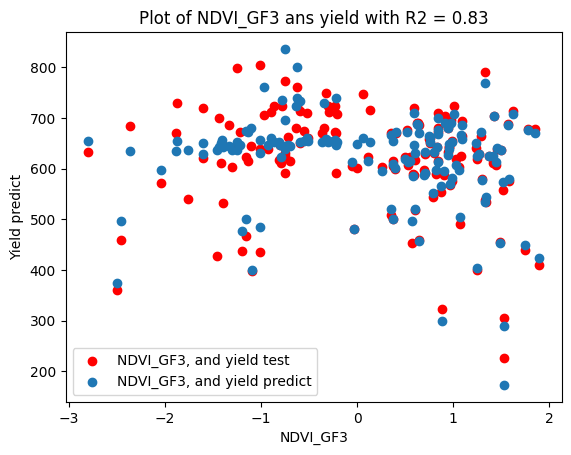

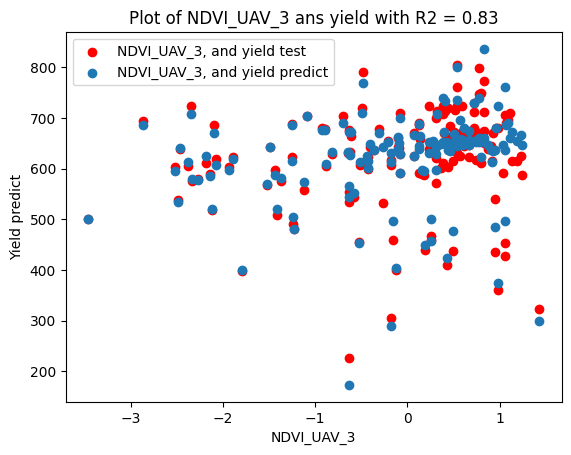

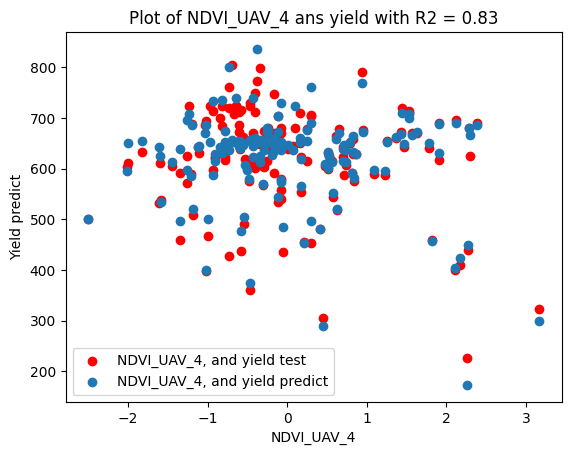

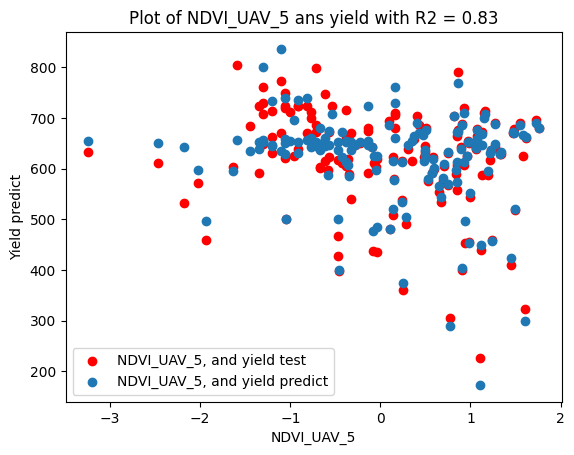

In [10]:
legend = PlotLegends()
legend.first_plot_label = "{variable}, and yield test"
legend.second_plot_label = "{variable}, and yield predict"
legend.title = "Plot of {variable} ans yield with R2 = {r2:.2f}"
legend.x_label = "{variable}"
legend.y_label = "Yield predict"
features = preprocessing.get_name_features()
metric.plot_r2_predicted(legend=legend, features=features)

Get the predict that are more bigger that .05

In [13]:
metric.list_percentage_error_upper(pivot=.04, sort = 'error')

[{'truth': 427.0, 'predict': 636.2508119243769, 'error': 0.4900487398697351},
 {'truth': 226.1118,
  'predict': 173.37623589187308,
  'error': 0.23322782848187007},
 {'truth': 532.0, 'predict': 643.3480682786758, 'error': 0.20930088022307478},
 {'truth': 799.0, 'predict': 652.7876470944561, 'error': 0.18299418386175703},
 {'truth': 804.0, 'predict': 657.0004341430741, 'error': 0.18283528091657447},
 {'truth': 540.0, 'predict': 637.2600484277726, 'error': 0.18011120079217155},
 {'truth': 749.0, 'predict': 658.1316435669111, 'error': 0.12131956800145385},
 {'truth': 748.0, 'predict': 659.9475471415843, 'error': 0.11771718296579636},
 {'truth': 625.0, 'predict': 697.1257468431016, 'error': 0.11540119494896262},
 {'truth': 436.0, 'predict': 484.1829312008478, 'error': 0.11051131009368763},
 {'truth': 670.0, 'predict': 739.6339481367378, 'error': 0.10393126587572804},
 {'truth': 729.0, 'predict': 654.146632116635, 'error': 0.10267951698678322},
 {'truth': 587.0, 'predict': 647.1964269030656